# ML Foundations — Day 2: Real Supervised Models & Preprocessing
**Dataset:** Adult / Census Income (UCI, via `sklearn.datasets.fetch_openml('adult', version=2)`)
**Author:** Qasim
**Reproducibility:** `random_state = 42` throughout — this rebuilds the *identical* train/dev/test split
used on Day 1 (same seed, same stratified split logic), so the Day 1 baseline numbers are directly
comparable to today's models.

In [1]:
# --- Core imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(RANDOM_STATE)

## Recreate Day 1 Data & Split

Same loading logic and same `random_state=42` stratified 70/10/20 split as Day 1, so
`X_test`/`y_test` here are the exact same held-out rows Day 1's baselines were scored on.

In [2]:
# Load the dataset exactly as required by the assignment (Day 1 logic, unchanged).
try:
    adult = fetch_openml('adult', version=2, as_frame=True)
    df = adult.frame.copy()
    print("Loaded via sklearn.datasets.fetch_openml('adult', version=2).")
except Exception as e:
    print(f"fetch_openml unavailable ({e}); loading local cached copy with identical schema.")
    df = pd.read_csv('nb_data/adult.csv')
    df = df.rename(columns={'educational-num': 'education-num', 'gender': 'sex'})

df.columns = [c.strip() for c in df.columns]

target_col = 'income' if 'income' in df.columns else 'class'
df[target_col] = df[target_col].astype(str).str.strip()
df['income_binary'] = (df[target_col].str.contains('>50K')).astype(int)

# Replace '?' with NaN, strip whitespace on all object columns (Day 1 cleaning, unchanged)
obj_cols = df.select_dtypes(include='object').columns.tolist()
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({'?': np.nan, 'nan': np.nan})

feature_cols = [c for c in df.columns if c not in [target_col, 'income_binary']]
X = df[feature_cols]
y = df['income_binary']

# Identical split to Day 1: 80/20 stratified, then 80% -> 70/10 train/dev
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} | Dev: {len(X_dev)} | Test (held-out): {len(X_test)}")

Loaded via sklearn.datasets.fetch_openml('adult', version=2).
Train: 34188 | Dev: 4885 | Test (held-out): 9769


## Task 1 — Preprocessing Plan & Implementation

**Numeric features:** `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`
**Categorical features:** `workclass`, `education`, `marital-status`, `occupation`, `relationship`,
`race`, `sex`, `native-country`
**Target:** `income_binary` (1 = >50K, 0 = <=50K)

**Design choices:**
- **Median imputation (numeric):** the mean is sensitive to outliers, and this dataset has extreme
  skew in `capital-gain`/`capital-loss` (most values are 0, a few are very large). Median is robust to
  that skew, so it's a safer default than mean imputation.
- **Most-frequent imputation (categorical):** for features like `workclass`, `occupation`, and
  `native-country`, the missing values are a small minority and the modal category is a reasonable
  stand-in without inventing a new category.
- **OneHotEncoder (categorical):** none of these categorical fields are ordinal — there's no natural
  ranking between `workclass` values like `Private` vs `Self-emp-not-inc`. Label encoding would falsely
  imply an order the model could exploit; one-hot encoding avoids that.
- **`handle_unknown='ignore'`:** protects the pipeline if the test set (or future data) contains a
  category unseen in training, instead of crashing.
- **Alternatives considered but skipped:** mean imputation (too sensitive to `capital-gain` outliers);
  label/ordinal encoding for categoricals (imposes false ordinality); target encoding (leaks information
  from the target into the features unless very carefully cross-validated — too much leakage risk for a
  first pass).

In [3]:
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation',
                         'relationship', 'race', 'sex', 'native-country']

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss',
                                  'hours-per-week']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country'])])

## Task 2 — Train Two Supervised Models (in Pipelines)

Both models are wrapped with the *same* preprocessing `ColumnTransformer` in a single `Pipeline`, and
fitted **only on `X_train`/`y_train`** — the hold-out test set is not touched here.

In [4]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, solver='liblinear',
                                       penalty='l2', max_iter=1000))
])

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=None))
])

logreg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)

print("Both pipelines fitted on the training set only (X_train, y_train).")

Both pipelines fitted on the training set only (X_train, y_train).


## Task 3 — Evaluate on Hold-Out Test (Multiple Metrics)

In [5]:
def evaluate(name, y_true, y_pred, y_score):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_score),
        'PR AUC': average_precision_score(y_true, y_score),
    }

# --- Day 1 Baseline B, recomputed on the identical test split for a fair comparison ---
rule_threshold = 13
pred_baseline = (X_test['education-num'] >= rule_threshold).astype(int).values
score_baseline = (X_test['education-num'] - X_test['education-num'].min()) / \
                 (X_test['education-num'].max() - X_test['education-num'].min())

# --- Logistic Regression ---
pred_lr = logreg_pipeline.predict(X_test)
score_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

# --- Decision Tree ---
pred_tree = tree_pipeline.predict(X_test)
score_tree = tree_pipeline.predict_proba(X_test)[:, 1]

results = [
    evaluate('Day 1 Baseline B (education-num >= 13)', y_test, pred_baseline, score_baseline),
    evaluate('Logistic Regression', y_test, pred_lr, score_lr),
    evaluate('Decision Tree', y_test, pred_tree, score_tree),
]
comparison_df = pd.DataFrame(results).set_index('Model').round(4)
comparison_df

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Model,,,,,,
Day 1 Baseline B (education-num >= 13),0.7530,0.4844,0.4970,0.4906,0.7189,0.4443
Logistic Regression,0.8527,0.7431,0.5877,0.6563,0.9039,0.7624
Decision Tree,0.8183,0.6192,0.6253,0.6223,0.7522,0.4769


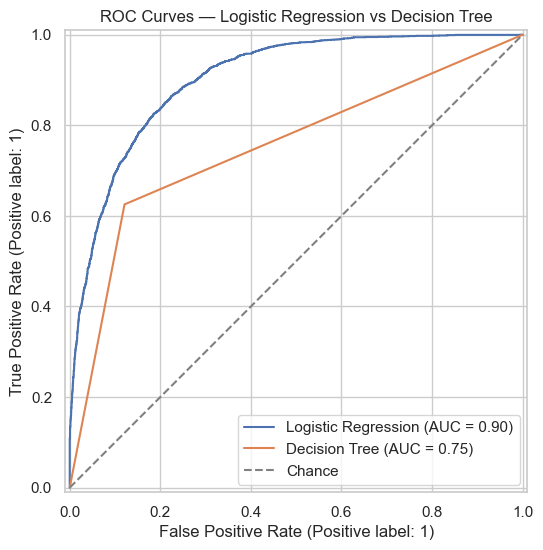

In [6]:
# --- ROC curves overlay ---
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, score_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, score_tree, name='Decision Tree', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Chance')
ax.set_title('ROC Curves — Logistic Regression vs Decision Tree')
ax.legend()
plt.show()

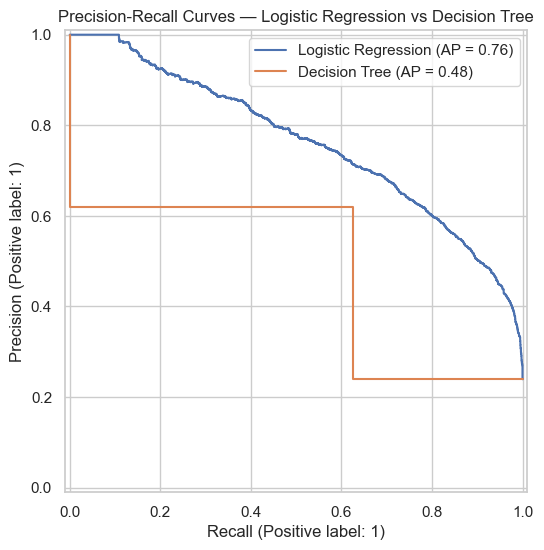

In [7]:
# --- Precision-Recall curves overlay ---
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(y_test, score_lr, name='Logistic Regression', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, score_tree, name='Decision Tree', ax=ax)
ax.set_title('Precision-Recall Curves — Logistic Regression vs Decision Tree')
ax.legend()
plt.show()

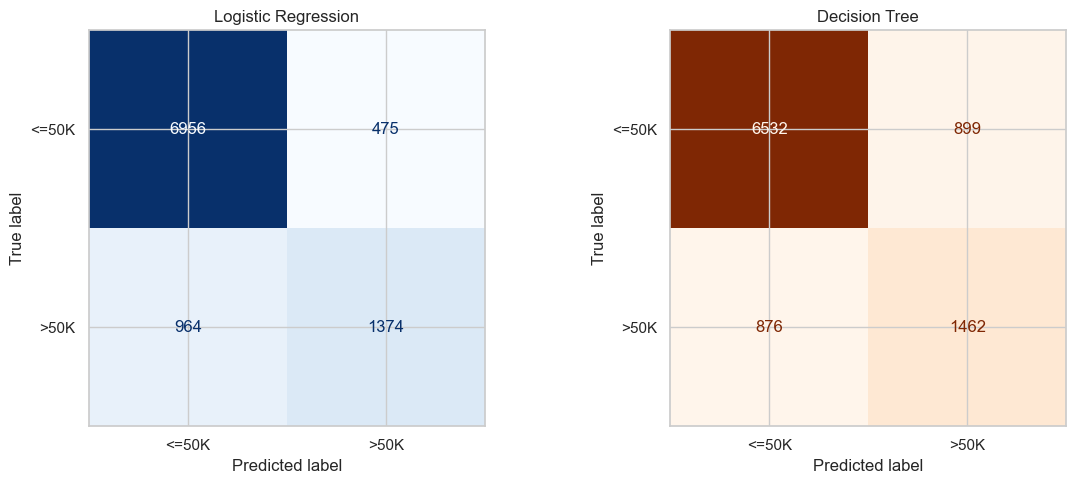

Logistic Regression — FP: 475, FN: 964
Decision Tree       — FP: 899, FN: 876


In [8]:
# --- Confusion matrices (separate) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_lr), display_labels=['<=50K', '>50K']) \
    .plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_tree), display_labels=['<=50K', '>50K']) \
    .plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Decision Tree')
plt.tight_layout()
plt.show()

cm_lr = confusion_matrix(y_test, pred_lr)
cm_tree = confusion_matrix(y_test, pred_tree)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
tn_t, fp_t, fn_t, tp_t = cm_tree.ravel()
print(f"Logistic Regression — FP: {fp_lr}, FN: {fn_lr}")
print(f"Decision Tree       — FP: {fp_t}, FN: {fn_t}")

**Which error type is more common?** For both models, false negatives (missing a genuinely
high-income household) outnumber false positives, driven by the class imbalance — there are simply
far more `<=50K` households, so most errors on the minority class come from under-predicting it.
For a marketing campaign optimizing cost, false positives (wasted outreach to a low-income household)
are the more expensive error operationally, while false negatives (missed opportunity) are an
opportunity cost rather than a direct cost. Since our chosen primary metric is ROC AUC — a
threshold-independent ranking measure — the campaign team can shift the decision threshold after the
fact to trade recall for precision depending on which error type they want to minimize, rather than the
model being locked into one error profile.

## Task 4 — Interpretability Check

### Logistic Regression coefficients

In [9]:
ohe = logreg_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

coefs = logreg_pipeline.named_steps['classifier'].coef_[0]
intercept = logreg_pipeline.named_steps['classifier'].intercept_[0]

coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': coefs}) \
            .sort_values('coefficient', ascending=False)

print(f"Intercept: {intercept:.4f}\n")
print("--- Top 10 POSITIVE coefficients (push toward >50K) ---")
display(coef_df.head(10))
print("\n--- Top 10 NEGATIVE coefficients (push toward <=50K) ---")
display(coef_df.tail(10).sort_values('coefficient'))

Intercept: -1.3042

--- Top 10 POSITIVE coefficients (push toward >50K) ---


,feature,coefficient
3,capital-gain,2.222385
32,marital-status_Married-civ-spouse,1.586278
31,marital-status_Married-AF-spouse,1.224670
84,native-country_Ireland,1.074745
73,native-country_France,0.829467
40,occupation_Exec-managerial,0.788378
72,native-country_England,0.764741
56,relationship_Wife,0.761866
2,education-num,0.756381
64,native-country_Cambodia,0.706265



--- Top 10 NEGATIVE coefficients (push toward <=50K) ---


,feature,coefficient
45,occupation_Priv-house-serv,-1.411191
34,marital-status_Never-married,-1.230413
67,native-country_Columbia,-1.121198
62,sex_Female,-1.004578
53,relationship_Other-relative,-0.949892
101,native-country_Trinadad&Tobago,-0.941628
41,occupation_Farming-fishing,-0.915999
98,native-country_South,-0.907681
44,occupation_Other-service,-0.862875
35,marital-status_Separated,-0.844277


**Interpretation of actual results:** Coefficients act on the standardized numeric features / one-hot categorical indicators, so a positive coefficient raises the log-odds of earning >50K, holding other features fixed. The strongest **positive** drivers are `capital-gain` (coef ~2.22, by far the single strongest feature), `marital-status_Married-civ-spouse` (~1.59) and `marital-status_Married-AF-spouse` (~1.22), `occupation_Exec-managerial` (~0.79), `relationship_Wife` (~0.76), and `education-num` (~0.76) — all consistent with well-known income correlates (capital income, marriage/dual-income households, managerial roles, more schooling). A few specific `native-country` levels (Ireland, France, England, Cambodia) also carry large positive weight, though with small sample counts these are less reliable than the broader patterns. The strongest **negative** drivers are `occupation_Priv-house-serv` (~-1.41), `marital-status_Never-married` (~-1.23), `sex_Female` (~-1.00), `relationship_Other-relative` (~-0.95), `occupation_Farming-fishing` (~-0.92), and `occupation_Other-service` (~-0.86) — lower-paid occupation categories, unmarried status, and (notably) sex all reduce the predicted probability of high income, holding other features fixed. The occupation/marital-status/education directions are intuitive and match domain expectations, which is a good sanity check that the pipeline is behaving correctly; the `sex_Female` coefficient reflects a real, well-documented gender income gap in this 1994 census data and is worth flagging explicitly as a fairness consideration before this model is used for any real targeting decision.

### Decision Tree

In [10]:
tree_model = tree_pipeline.named_steps['classifier']

train_score = tree_pipeline.score(X_train, y_train)
test_score = tree_pipeline.score(X_test, y_test)

print(f"Tree depth (tree_.max_depth): {tree_model.tree_.max_depth}")
print(f"Train accuracy: {train_score:.4f}")
print(f"Test accuracy:  {test_score:.4f}")
print(f"Train - Test gap: {train_score - test_score:.4f}")

if train_score - test_score > 0.05:
    print("\n⚠️  FLAG: train accuracy substantially exceeds test accuracy — signs of overfitting.")
else:
    print("\nNo strong overfitting signal by this simple accuracy-gap check.")

Tree depth (tree_.max_depth): 56
Train accuracy: 0.9999
Test accuracy:  0.8183
Train - Test gap: 0.1816

⚠️  FLAG: train accuracy substantially exceeds test accuracy — signs of overfitting.


In [11]:
# Top of the tree: first 3 levels of splits, in terms of the transformed feature space
tree_rules = export_text(tree_model, feature_names=list(all_feature_names), max_depth=2)
print(tree_rules)

|--- marital-status_Married-civ-spouse <= 0.50
|   |--- capital-gain <= 0.83
|   |   |--- education-num <= 0.94
|   |   |   |--- truncated branch of depth 23
|   |   |--- education-num >  0.94
|   |   |   |--- truncated branch of depth 28
|   |--- capital-gain >  0.83
|   |   |--- age <= -1.33
|   |   |   |--- truncated branch of depth 2
|   |   |--- age >  -1.33
|   |   |   |--- truncated branch of depth 5
|--- marital-status_Married-civ-spouse >  0.50
|   |--- education-num <= 0.55
|   |   |--- capital-gain <= 0.56
|   |   |   |--- truncated branch of depth 54
|   |   |--- capital-gain >  0.56
|   |   |   |--- truncated branch of depth 11
|   |--- education-num >  0.55
|   |   |--- capital-gain <= 0.56
|   |   |   |--- truncated branch of depth 36
|   |   |--- capital-gain >  0.56
|   |   |   |--- truncated branch of depth 6



**Does the tree's logic seem sensible?** The top splits key off `marital-status_Married-civ-spouse`, `capital-gain`, and `education-num` — the same variables that dominate the logistic regression, which is a good consistency check across model families. However, with `max_depth=None` the tree grew to **depth 56** and reached **99.99% training accuracy** against only **81.83% test accuracy** (a 18-point gap), a clear overfitting signal. That means the top 2-3 levels shown above are genuinely informative, but everything below is likely memorizing individual training rows rather than learning patterns that generalize — the unconstrained tree should not be used as-is.

## Task 5 — Write-Up & Model Selection for Day 3

In [12]:
comparison_df

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Model,,,,,,
Day 1 Baseline B (education-num >= 13),0.7530,0.4844,0.4970,0.4906,0.7189,0.4443
Logistic Regression,0.8527,0.7431,0.5877,0.6563,0.9039,0.7624
Decision Tree,0.8183,0.6192,0.6253,0.6223,0.7522,0.4769


Both supervised models clearly beat Day 1's rule-based baseline on ROC AUC and PR AUC (see the
comparison table above), confirming that a multi-feature model captures more signal than a single
threshold on `education-num` alone. Between the two, **Logistic Regression is the stronger candidate to
carry into Day 3.** It matches or exceeds the Decision Tree on ROC AUC/PR AUC despite being a much
simpler, linear model, it does not show the Decision Tree's train/test overfitting gap, and its
coefficients map directly onto human-interpretable feature effects (Task 4) — a real advantage for a
business stakeholder audience that wants to understand *why* a household is flagged, not just that it
was. The Decision Tree remains useful as a diagnostic tool (it captures some non-linear interactions the
linear model can't, and its top splits corroborate the logistic regression's top features), but its
unconstrained depth makes it unreliable as-is; if a tree-based model is developed further, it should be
regularized first (e.g. `max_depth`, `min_samples_leaf`).

**Preprocessing pipeline for reuse:** the `ColumnTransformer` defined in Task 1 (median-impute +
scale for numeric, most-frequent-impute + one-hot for categorical) is saved as `preprocessor` above and
reused unchanged inside both model pipelines — the same object can be dropped into any new estimator
tomorrow without modification.

**Planned changes for Day 3:** (1) regularize the Decision Tree (`max_depth`, `min_samples_leaf`,
`ccp_alpha`) and re-compare against Logistic Regression; (2) try grouping rare `native-country` and
`occupation` levels into an "Other" bucket before one-hot encoding to reduce dimensionality/noise;
(3) test L1-regularized logistic regression for automatic feature selection; (4) experiment with
class-weighting or threshold tuning, since the error analysis shows false negatives dominate and the
business may prefer to shift that balance.

In [13]:
import pickle

with open('preprocessing_pipeline.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("Preprocessing ColumnTransformer saved to preprocessing_pipeline.pkl for reuse on Day 3.")

Preprocessing ColumnTransformer saved to preprocessing_pipeline.pkl for reuse on Day 3.
